In [15]:
!pip install --pre mesa[viz]
!pip install numpy scipy matplotlib seaborn scikit-learn mesa==3.0 -q

# Requiero Mesa > 3.0.3
# Importamos las clases que se requieren para manejar los agentes (Agent) y su entorno (Model).
# Cada modelo puede contener múltiples agentes.
from mesa import Agent, Model

# Debido a que necesitamos que existe un solo agente por celda, elegimos ''Multigrid''.
from mesa.space import MultiGrid

# Con ''RandomActivation'', hacemos que todos los agentes se activen de forma aleatoria.
from mesa.time import RandomActivation

# Haremos uso de ''DataCollector'' para obtener información de cada paso de la simulación.
from mesa.datacollection import DataCollector

# Haremos uso de ''batch_run'' para ejecutar varias simulaciones
from mesa.batchrunner import batch_run

# matplotlib lo usaremos crear una animación de cada uno de los pasos del modelo.
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"
matplotlib.rcParams['animation.embed_limit'] = 2**128

# Importamos los siguientes paquetes para el mejor manejo de valores numéricos.
import numpy as np
import pandas as pd
import seaborn as sns
sns.set()

# Definimos otros paquetes que vamos a usar para medir el tiempo de ejecución de nuestro algoritmo.
import time
import datetime

import matplotlib.patches as patches
from mesa.time import BaseScheduler, RandomActivation

In [16]:
#Hay funciones en este codigo que utilizaron Ai

#===Agente===
class Survivor(Agent):
  # Inicializa un sobreviviente con atributos como posición, puntos de acción (AP), estado, etc.
    def __init__(self, model, unique_id):
        self.last_pos = None
        self.model = model
        self.unique_id = unique_id
        self.victimInHand = False
        self.AP = 4
        self.status = "active"
        self.pos = None

# Define las acciones que realiza el sobreviviente en cada paso del turno (abrir puertas, moverse, etc.)
    def step(self):
        if self.status != "active":
            return

        x, y = self.pos
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            nx, ny = x + dx, y + dy
            if (0 <= nx < self.model.grid.width and 0 <= ny < self.model.grid.height and
                self.model.door_grid[nx][ny] == 1):  # Closed door
                if self.AP >= 1:
                    self.model.door_grid[nx][ny] = 2  # Open door
                    self.AP -= 1
                    print(f"Survivor {self.unique_id} opened door at ({nx}, {ny})")
                    break

        carry_cost = 2 if self.victimInHand else 1


        x, y = self.pos

        if self.model.zombie_grid[x][y] > 0 and self.status == "active":
            self.AP -= 2

        if self.model.door_grid[x][y] == 1 and self.status == "active":
            self.model.door_grid[x][y] = 2
            self.AP -= 1

        if self.model.zombie_grid[x][y] > 0 and self.AP == 1:
            return

        if self.model.zombie_grid[x][y] > 0 and self.AP == 2:
            return

        self.move()

# Gestiona todo el comportamiento de movimiento, incluyendo decisiones estratégicas y aleatorias.
#En esta funcion se utilizo IA
    def move(self):
      if self.AP <= 0:
          return

      # If carrying a victim, prioritize safe zones with some randomness
      if self.victimInHand:
          safe_zones = [(0, 3), (0, 4), (0, 5), (0, 6), (3, 7), (3, 8), (9, 3), (9, 4)]
          safe_zones_list = list(safe_zones)
          self.random.shuffle(safe_zones_list)
          safe_steps = [step for step in safe_zones_list if self.can_move_to(*step)]

          if safe_steps:
              if self.random.random() < 0.7:
                  target = min(safe_steps, key=lambda step: abs(step[0] - self.pos[0]) + abs(step[1] - self.pos[1]))
              else:
                  target = self.random.choice(safe_steps)
              self.move_toward(target)
              return

      # Get possible steps and shuffle them for randomness
      possible_steps = self.model.grid.get_neighborhood(
          self.pos,
          moore=False,
          include_center=False
      )
      possible_steps_list = list(possible_steps)
      self.random.shuffle(possible_steps_list)

      # Add door closing as a strategic option when carrying victims
      if self.victimInHand:
          # Check if we should close doors behind us for protection
          x, y = self.pos
          for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
              nx, ny = x + dx, y + dy
              if (0 <= nx < self.model.grid.width and 0 <= ny < self.model.grid.height and
                  self.model.door_grid[nx][ny] == 2 and  # Open door
                  self.AP >= 1 and
                  self.random.random() < 0.3):
                  self.close_door(nx, ny)

      # Check for containment spots if carrying victim (with randomness)
      if self.victimInHand:
          containment_spots = [(0, 5), (0, 6), (9, 3), (9, 4), (3, 7), (3, 8), (0, 3), (0, 4)]
          containment_list = list(containment_spots)
          self.random.shuffle(containment_list)
          valid_spots = [spot for spot in containment_list if self.can_move_to(spot[0], spot[1])]

          if valid_spots:
              if self.random.random() < 0.6:
                  final_move = min(valid_spots, key=lambda s: abs(s[0] - self.pos[0]) + abs(s[1] - self.pos[1]))
              else:
                  final_move = self.random.choice(valid_spots)

              old_pos = self.pos
              self.model.grid.move_agent(self, final_move)
              self.AP -= 1
              print(f"Survivor {self.unique_id} carried victim from {old_pos} to {final_move}, AP left: {self.AP}")

              if final_move in containment_spots:
                  self.victimInHand = False
                  self.model.victims_rescued += 1
                  print(f"Survivor {self.unique_id} rescued victim at {final_move}!")
              return

      # Categorize steps (using the shuffled list)
      poi_steps = []
      empty_steps = []
      zombie_steps = []

      for step in possible_steps_list:
          if not self.can_move_to(step[0], step[1]):
              continue

          x, y = step
          if self.model.poi_grid[x][y] == 1:
              poi_steps.append(step)
          elif self.model.zombie_grid[x][y] > 0:
              zombie_steps.append(step)
          else:
              empty_steps.append(step)

      rand_val = self.random.random()

      # Prioritize POIs with some randomness
      if poi_steps and rand_val < 0.8:
          final_move = self.random.choice(poi_steps)
          print(f"Survivor {self.unique_id} moving toward POI at {final_move}")
      # Sometimes choose empty spaces even when POIs are available
      elif empty_steps and rand_val < 0.9:
          final_move = self.random.choice(empty_steps)
      # Consider zombies only if enough AP and with some probability
      elif zombie_steps and self.AP >= 2 and rand_val < 0.4:
          final_move = self.random.choice(zombie_steps)
          print(f"Survivor {self.unique_id} moving toward zombie at {final_move}")
      # Fallbacks
      elif empty_steps:
          final_move = self.random.choice(empty_steps)
      elif poi_steps:
          final_move = self.random.choice(poi_steps)
          print(f"Survivor {self.unique_id} moving toward POI at {final_move}")
      elif zombie_steps and self.AP >= 2:
          final_move = self.random.choice(zombie_steps)
          print(f"Survivor {self.unique_id} moving toward zombie at {final_move}")
      else:
          print(f"Survivor {self.unique_id} has no valid moves from {self.pos}")
          return

      old_pos = self.pos
      self.model.grid.move_agent(self, final_move)
      self.AP -= 1
      print(f"Survivor {self.unique_id} moved from {old_pos} to {final_move}, AP left: {self.AP}")

      new_x, new_y = self.pos
      if self.model.poi_grid[new_x][new_y] == 1:
          self.reveal_poi(new_x, new_y)
      elif self.model.zombie_grid[new_x][new_y] > 0:
          print(f"Survivor {self.unique_id} encountered zombie at ({new_x}, {new_y})")
          if self.attack_zombie(new_x, new_y, "adjacent"):
              print(f"Survivor {self.unique_id} attacked zombie successfully!")
          else:
              print(f"Survivor {self.unique_id} didn't have enough AP to attack zombie")


# Verifica si el sobreviviente puede moverse a una celda específica (considerando muros y puertas).
    def can_move_to(self, target_x, target_y):
      # Check grid bounds first
      if not (0 <= target_x < self.model.grid.width and 0 <= target_y < self.model.grid.height):
          return False

      dx = target_x - self.pos[0]
      dy = target_y - self.pos[1]

      NORTH, EAST, SOUTH, WEST = self.model.NORTH, self.model.EAST, self.model.SOUTH, self.model.WEST

      # Check walls from current position
      if dx == 1 and (self.model.wall_grid[self.pos[0]][self.pos[1]] & EAST):
          return False
      elif dx == -1 and (self.model.wall_grid[self.pos[0]][self.pos[1]] & WEST):
          return False
      elif dy == 1 and (self.model.wall_grid[self.pos[0]][self.pos[1]] & SOUTH):
          return False
      elif dy == -1 and (self.model.wall_grid[self.pos[0]][self.pos[1]] & NORTH):
          return False

      # Check walls from target position
      if dx == 1 and (self.model.wall_grid[target_x][target_y] & WEST):
          return False
      elif dx == -1 and (self.model.wall_grid[target_x][target_y] & EAST):
          return False
      elif dy == 1 and (self.model.wall_grid[target_x][target_y] & NORTH):
          return False
      elif dy == -1 and (self.model.wall_grid[target_x][target_y] & SOUTH):
          return False

      # Check doors
      if self.model.door_grid[target_x][target_y] == 1:
          return False

      return True

# Revela un punto de interés (POI); puede ser una víctima o una falsa alarma.
    def reveal_poi(self, x, y):
      is_victim = self.random.random() < 0.7

      if is_victim:
          self.model.poi_grid[x][y] = 0
          print(f"Survivor {self.unique_id} found a victim at ({x}, {y})!")

          if self.has_firefighter_ability():
              self.model.victims_rescued += 1
              print(f"Firefighter immediately rescued the victim!")
          else:
              self.victimInHand = True
              print(f"Survivor {self.unique_id} picked up a victim at ({x}, {y})!")
      else:
          self.model.poi_grid[x][y] = 0
          print(f"Survivor {self.unique_id} found a false alarm at ({x}, {y})!")

          if self.has_firefighter_ability():
              print(f"Firefighter disabled the false alarm!")

# Determina si el sobreviviente es sobreviviente
    def has_firefighter_ability(self):
        return self.unique_id == 0

# Permite al sobreviviente romper un muro en una dirección específica, con dos fases de daño.
    def break_wall(self, x, y, direction):
        if self.AP < 1:
            return False

        wall_value = self.model.wall_grid[x][y]
        direction_mask = {
            "NORTH": self.model.NORTH,
            "EAST": self.model.EAST,
            "SOUTH": self.model.SOUTH,
            "WEST": self.model.WEST
        }[direction]

        if wall_value & direction_mask:
          current_damage = self.model.wall_damage_grid[x][y]

          if current_damage < 1:
            self.model.wall_damage_grid[x][y] = 1
            self.model.total_damage += 1
            self.AP -= 1
            print(f"Wall at ({x}, {y}) damaged (1/2), total damage: {self.model.total_damage}/24")
            return True

          else:
            self.model.wall_grid[x][y] &= ~direction_mask
            self.model.wall_damage_grid[x][y] = 0
            self.model.total_damage += 1
            self.AP -= 1
            print(f"Wall at ({x}, {y}) destroyed, total damage: {self.model.total_damage}/24")
            return True

        return False
# Permite cerrar una puerta abierta si hay suficiente AP.
    def close_door(self, x, y):
        if self.model.door_grid[x][y] == 2 and self.AP >= 1:  # Open door
            self.model.door_grid[x][y] = 1  # Close door
            self.AP -= 1
            print(f"Survivor {self.unique_id} closed door at ({x}, {y})")
            return True
        return False

# Realiza un ataque a un zombie adyacente (varía el costo de AP según el tipo de zombie).
    def attack_zombie(self, x, y, attack_type):
        target_x, target_y = x, y

        if attack_type == "adjacent":
            for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
                nx, ny = self.pos[0] + dx, self.pos[1] + dy
                if (0 <= nx < self.model.grid.width and
                    0 <= ny < self.model.grid.height and
                    self.model.zombie_grid[nx][ny] > 0):
                    target_x, target_y = nx, ny
                    break

        zombie_type = self.model.zombie_grid[target_x][target_y]

        if zombie_type == 1 and self.AP >= 1:
            self.model.zombie_grid[target_x][target_y] = 0
            self.AP -= 1
            return True
        elif zombie_type >= 2 and self.AP >= 2:
            self.model.zombie_grid[target_x][target_y] = 0
            self.AP -= 2
            return True

        return False

# Se mueve hacia una posición objetivo de forma eficiente, evitando obstáculos.
    def move_toward(self, target):
      current_x, current_y = self.pos
      target_x, target_y = target

      possible_moves = []

      for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
          new_x, new_y = current_x + dx, current_y + dy

          if (self.can_move_to(new_x, new_y) and
              (abs(new_x - target_x) + abs(new_y - target_y)) <
              (abs(current_x - target_x) + abs(current_y - target_y))):
              possible_moves.append((new_x, new_y))

      if possible_moves:
          best_move = min(possible_moves, key=lambda pos:
                        abs(pos[0] - target_x) + abs(pos[1] - target_y))

          old_pos = self.pos
          self.model.grid.move_agent(self, best_move)
          self.AP -= 1
          print(f"Survivor {self.unique_id} moved from {old_pos} to {best_move} toward target, AP left: {self.AP}")

          safe_zones = [(0, 3), (0, 4), (0, 5), (0, 6), (3, 7), (3, 8), (9, 3), (9, 4)]
          if self.pos in safe_zones and self.victimInHand:
              self.victimInHand = False
              self.model.victims_rescued += 1
              print(f"Survivor {self.unique_id} rescued victim at {self.pos}!")

          return True

      return False

In [17]:
#=== Modelo ===
class FlashGame(Model):
    # Constructor principal del modelo; inicializa el estado del juego y su configuración inicial.
    def __init__(self, width=9, height=7, stats=None):
        super().__init__()

        if stats is not None:
            self.stats = stats
        else:
            self.stats = SimpleGameStats()

        self.grid = MultiGrid(width, height, torus=False)
        self.schedule = BaseScheduler(self)
        self.current_survivor_index = 0

        self.victims_rescued = 0
        self.victims_lost = 0
        self.total_damage = 0
        self.current_turn = 0

        self.door_states = {}
        self.door_damage = {}


        self.door_grid = np.zeros((width, height), dtype=int)
        self.wall_grid = np.zeros((width, height), dtype=int)
        self.zombie_grid = np.zeros((width, height), dtype=int)
        self.poi_grid = np.zeros((width, height), dtype=int)
        self.wall_damage_grid = np.zeros((width, height), dtype=int)

        self.zombie_spawn_tiles = [(width-1, height-1), (width-1, 0), (0, height-1), (0, 0)]
        self.killer_zombies_created = False
        self.forbidden_positions = {(x, y) for x in range(width) for y in range(height) if x in {0, 9} or y in {0, 7}}

        self.NORTH = 1
        self.EAST = 2
        self.SOUTH = 4
        self.WEST = 8

        from mesa.datacollection import DataCollector
        self.datacollector = DataCollector(
            model_reporters={"Grid": lambda m: self.get_visualization_grid()}
            )

        self._setup_board()
        self._create_survivors()

  # Retorna una cuadrícula numérica para visualizar el estado del juego (muros, puertas, zombies, POIs, sobrevivientes).
    def get_visualization_grid(self):
      vis_grid = np.zeros((self.grid.height, self.grid.width),dtype= int)

      for x in range(self.grid.width):
        for y in range(self.grid.height):
            cell_value = 0

            # Walls
            if self.wall_grid[x][y] != 0:
                cell_value = 1

            # Doors
            if self.door_grid[x][y] == 1:
                cell_value = 2
            elif self.door_grid[x][y] == 2:
                cell_value = 3

            # Zombies
            if self.zombie_grid[x][y] == 1:
                cell_value = 4
            elif self.zombie_grid[x][y] == 2:
                cell_value = 5
            elif self.zombie_grid[x][y] == 3:
                cell_value = 6

            # POIs
            if self.poi_grid[x][y] == 1:
                cell_value = 7
            elif self.poi_grid[x][y] == 2:
                cell_value = 8
            elif self.poi_grid[x][y] == 3:
                cell_value = 9

            # Survivors
            cell_agents = self.grid.get_cell_list_contents([(x, y)])
            survivors = [a for a in cell_agents if isinstance(a, Survivor)]
            if survivors:
                if survivors[0].victimInHand:
                    cell_value = 11
                else:
                    cell_value = 10

            vis_grid[y][x] = cell_value

      return vis_grid

  # Configura el tablero inicial: coloca muros, puertas y ajusta direcciones.
    def _setup_board(self):
        NORTH, EAST, SOUTH, WEST = self.NORTH, self.EAST, self.SOUTH, self.WEST

        # Clear any existing walls
        self.wall_grid = np.zeros((self.grid.width, self.grid.height), dtype=int)
        self.door_grid = np.zeros((self.grid.width, self.grid.height), dtype=int)
        self.door_states = {}
        self.door_damage = {}

        # Define your walls
        walls = {(1,1,"S"), (2,1,"S"), (4,1,"S"), (5,1,"S"), (6,1,"S"), (7,1,"S"), (8,1,"S"),
                (1,0,"N"), (2,0,"N"), (4,0,"N"), (5,0,"N"), (6,0,"N"), (7,0,"N"), (8,0,"N"),
                (1,6,"N"), (2,6,"N"), (3,6,"N"), (4,6,"N"), (5,6,"N"), (7,6,"N"), (8,1,"N"),
                (1,7,"S"), (2,7,"S"), (3,7,"S"), (4,7,"S"), (5,7,"S"), (7,7,"S"), (8,7,"S"),
                (1,1,"W"), (1,2,"W"), (1,3,"W"), (1,5,"W"), (1,6,"W"), (1,7,"W"),
                (0,1,"E"), (0,2,"E"), (0,3,"E"), (0,5,"E"), (0,6,"E"), (1,7,"E"),
                (9,1,"W"), (9,2,"W"), (9,4,"W"), (9,5,"W"), (9,6,"W"), (9,7,"W"),
                (8,1,"E"), (8,2,"E"), (8,4,"E"), (8,5,"E"), (8,6,"E"), (8,7,"E"),
                (3,5,"E"),(4,5,"W"),(5,6,"E"),(6,6,"W"),(2,3,"E"),(3,3,"W"),(6,4,"E"),(7,4,"W"),(5,2,"E"),(6,2,"W"),(7,2,"E"),(8,2,"W"),
                (3,2,"N"),(3,3,"S"),(2,2,"N"), (2,3,"S") ,(1,2,"N"),(1,3,"S"),(5,2,"N"),(5,3,"S"),(6,2,"N"),(6,3,"S"),(7,2,"N"),(7,3,"S"),
                (8,2,"N"),(8,3,"S"),(3,4,"N"),(3,5,"S"),(4,4,"N"),(4,5,"S"),(5,4,"N"),(5,5,"S"),(6,4,"N"),(6,5,"S"),(7,4,"N"),(7,5,"S")
                }

        # Apply walls to the grid
        for x, y, direction in walls:
            if not (0 <= x < self.grid.width and 0 <= y < self.grid.height):
                continue

            if direction == "N":
                self.wall_grid[x][y] |= NORTH
            elif direction == "E":
                self.wall_grid[x][y] |= EAST
            elif direction == "S":
                self.wall_grid[x][y] |= SOUTH
            elif direction == "W":
                self.wall_grid[x][y] |= WEST

        # Add doors with proper placement
        doors = {(3,6,"E"), (4,6,"W"), (5,5,"E"), (5,6,"W"), (2,4,"E"), (3,4,"W"),
                 (5,1,"E"), (6,1,"W"), (7,1,"E"), (8,1,"W"), (4,2,"N"), (4,3,"S"),
                 (8,4,"N"), (8,5,"S"), (6,3,"E"), (7,3,"W")}

        for x, y, direction in doors:
            if not (0 <= x < self.grid.width and 0 <= y < self.grid.height):
                continue

            # Mark this as a door position
            self.door_grid[x][y] = 1  # Start with closed door
            self.door_states[(x, y, direction)] = "closed"
            self.door_damage[(x, y, direction)] = 0

            # Remove the wall in that direction since it's a door
            if direction == "N":
                self.wall_grid[x][y] &= ~NORTH
                # Also remove the wall from the adjacent cell
                if y > 0:
                    self.wall_grid[x][y-1] &= ~SOUTH
            elif direction == "E":
                self.wall_grid[x][y] &= ~EAST
                if x < self.grid.width - 1:
                    self.wall_grid[x+1][y] &= ~WEST
            elif direction == "S":
                self.wall_grid[x][y] &= ~SOUTH
                if y < self.grid.height - 1:
                    self.wall_grid[x][y+1] &= ~NORTH
            elif direction == "W":
                self.wall_grid[x][y] &= ~WEST
                if x > 0:
                    self.wall_grid[x-1][y] &= ~EAST

  # Crea los sobrevivientes en sus posiciones iniciales y los agrega al scheduler y al grid.
    def _create_survivors(self):
        start_positions = [(0, 3), (0, 4), (3, 7), (9, 4), (6, 0), (7, 0)]
        for i, pos in enumerate(start_positions):
            survivor = Survivor(self, i)
            self.schedule.add(survivor)
            self.grid.place_agent(survivor, pos)

  # Genera nuevos zombies en el mapa, evitando ciertas casillas y respetando reglas de aparición.
    def spawn_zombies(self, safe_turn=0):
      if self.total_damage >= 24:
          return

      print("Spawning zombies...")
      valid_spawn_locations = []

      for x in range(self.grid.width):
          for y in range(self.grid.height):
              # Skip forbidden positions, walls, doors, zombies
              if ((x, y) in self.forbidden_positions or
                  self.door_grid[x][y] == 1 or
                  self.wall_grid[x][y] != 0 or
                  self.zombie_grid[x][y] > 0):
                  continue

              if safe_turn == 0 and self.poi_grid[x][y] > 0:
                  continue

              valid_spawn_locations.append((x, y))

      if not valid_spawn_locations:
          return

      self.random.shuffle(valid_spawn_locations)

      for _ in range(2):  # spawn 2 zombies
          spawn_x, spawn_y = self.random.choice(valid_spawn_locations)

          if self.poi_grid[spawn_x][spawn_y] in [1, 2]:
              self.victims_lost += 1
              self.poi_grid[spawn_x][spawn_y] = 0
              print(f"Victim lost to zombie spawn at ({spawn_x},{spawn_y})")

          if self.zombie_grid[spawn_x][spawn_y] == 0:
              self.zombie_grid[spawn_x][spawn_y] = 1
              print(f"New sleeping zombie at ({spawn_x},{spawn_y})")
          elif self.zombie_grid[spawn_x][spawn_y] == 1:
              self.zombie_grid[spawn_x][spawn_y] = 2
              print(f"Sleeping → active zombie at ({spawn_x},{spawn_y})")
          elif self.zombie_grid[spawn_x][spawn_y] == 2:
              self.handle_explosion(spawn_x, spawn_y)


  # Propaga los zombies activos a celdas vecinas. Consume los Poi e incluso es la causa de explosion
    def spread_zombies(self):
      if self.total_damage >= 24:
          return

      print("Zombies spreading...")
      new_zombie_grid = np.copy(self.zombie_grid)

      for x in range(self.grid.width):
          for y in range(self.grid.height):
              current = self.zombie_grid[x][y]

              if current == 0:
                  continue

              if current >= 2:  # Active zombie spreads
                  for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
                      nx, ny = x + dx, y + dy
                      if not (0 <= nx < self.grid.width and 0 <= ny < self.grid.height):
                          continue
                      if self.is_path_blocked(x, y, nx, ny):
                          continue

                      if self.poi_grid[nx][ny] in [1, 2]:
                          print(f"Victim consumed at ({nx},{ny})")
                          self.victims_lost += 1
                          self.poi_grid[nx][ny] = 0

                      if new_zombie_grid[nx][ny] == 0:
                          new_zombie_grid[nx][ny] = 1
                      elif new_zombie_grid[nx][ny] == 1:
                          new_zombie_grid[nx][ny] = 2
                      elif new_zombie_grid[nx][ny] == 2:
                          print(f"EXPLOSION during spread at ({nx},{ny})")
                          self.handle_explosion(nx, ny)

      self.zombie_grid = new_zombie_grid
      self.replenish_pois()

 # Maneja el efecto de una explosión causada por zombies asesinos.
    def handle_explosion(self, x, y):
      # Spread in 4 directions
      for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
          nx, ny = x + dx, y + dy
          if not (0 <= nx < self.grid.width and 0 <= ny < self.grid.height):
              continue

          if self.door_grid[nx][ny] in [1, 2]:
              print(f"Explosion destroyed door at ({nx},{ny})")
              self.door_grid[nx][ny] = 0
              continue

          if self.wall_grid[nx][ny] != 0:
              print(f"Explosion damaged wall at ({nx},{ny})")
              self.break_wall(nx, ny, "NORTH", is_zombie=True)
              continue

          if self.zombie_grid[nx][ny] == 0:
              self.zombie_grid[nx][ny] = 2
              print(f"Explosion spread: active zombie at ({nx},{ny})")

    # Verifica si el camino entre dos celdas está bloqueado por un muro o puerta cerrada.
    def is_path_blocked(self, from_x, from_y, to_x, to_y):
        dx, dy = to_x - from_x, to_y - from_y

        # Check walls from starting position
        if dx == 1 and (self.wall_grid[from_x][from_y] & self.EAST):
            return True
        elif dx == -1 and (self.wall_grid[from_x][from_y] & self.WEST):
            return True
        elif dy == 1 and (self.wall_grid[from_x][from_y] & self.SOUTH):
            return True
        elif dy == -1 and (self.wall_grid[from_x][from_y] & self.NORTH):
            return True

        # Check walls from target position
        if dx == 1 and (self.wall_grid[to_x][to_y] & self.WEST):
            return True
        elif dx == -1 and (self.wall_grid[to_x][to_y] & self.EAST):
            return True
        elif dy == 1 and (self.wall_grid[to_x][to_y] & self.NORTH):
            return True
        elif dy == -1 and (self.wall_grid[to_x][to_y] & self.SOUTH):
            return True

        # Check doors
        if self.door_grid[to_x][to_y] == 1:  # Closed door
            return True

        return False

    # Zombies asesinos pueden romper puertas o muros cercanos.
    #Se utilizo AI en esta fucnión.
    def killer_zombie_break_walls(self, x, y):
      # First check for doors to break
      for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
          nx, ny = x + dx, y + dy

          if not (0 <= nx < self.grid.width and 0 <= ny < self.grid.height):
              continue

          # Check if there's a door here
          if self.door_grid[nx][ny] in [1, 2]:  # Closed or open door
              print(f"Killer zombie breaking door at ({nx},{ny})!")
              self.door_grid[nx][ny] = 0  # Destroy door

              # Remove door from tracking
              keys_to_remove = []
              for key in list(self.door_states.keys()):
                  if key[0] == nx and key[1] == ny:
                      keys_to_remove.append(key)

              for key in keys_to_remove:
                  del self.door_states[key]
                  if key in self.door_damage:
                      del self.door_damage[key]

              return True

      # If no doors found, look for walls to break
      for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
          nx, ny = x + dx, y + dy

          if not (0 <= nx < self.grid.width and 0 <= ny < self.grid.height):
              continue

          # Check if there's any wall here
          if self.wall_grid[nx][ny] != 0:
              wall_directions = []

              # Zombie is north of the wall cell, so break the south wall of that cell
              if dy == 1:
                  if self.wall_grid[nx][ny] & self.SOUTH:
                      wall_directions.append("SOUTH")

              # Zombie is south of the wall cell, so break the north wall of that cell
              elif dy == -1:
                  if self.wall_grid[nx][ny] & self.NORTH:
                      wall_directions.append("NORTH")

              # Zombie is east of the wall cell, so break the west wall of that cell
              elif dx == 1:
                  if self.wall_grid[nx][ny] & self.WEST:
                      wall_directions.append("WEST")

              # Zombie is west of the wall cell, so break the east wall of that cell
              elif dx == -1:
                  if self.wall_grid[nx][ny] & self.EAST:
                      wall_directions.append("EAST")

              if wall_directions:
                  direction = self.random.choice(wall_directions)
                  if self.break_wall(nx, ny, direction, is_zombie=True):
                      print(f"Killer zombie broke wall at ({nx}, {ny}) in {direction} direction")
                      return True

      return False

    # Daña o destruye un muro en una dirección específica.
    def break_wall(self, x, y, direction, is_zombie=False):
      if not is_zombie and self.AP < 1:
          return False

      wall_value = self.wall_grid[x][y]
      direction_mask = {
          "NORTH": self.NORTH,
          "EAST": self.EAST,
          "SOUTH": self.SOUTH,
          "WEST": self.WEST
      }[direction]

      if wall_value & direction_mask:
          if self.wall_damage_grid[x][y] < 1:
              self.wall_damage_grid[x][y] = 1
              if not is_zombie:
                  self.AP -= 1
              print(f"Wall at ({x}, {y}) damaged (1/2), total damage: {self.total_damage}/24")
              return True
          else:
              self.wall_grid[x][y] &= ~direction_mask
              self.wall_damage_grid[x][y] = 0
              self.total_damage += 1
              if not is_zombie:
                  self.AP -= 1
              print(f"Wall at ({x}, {y}) destroyed, total damage: {self.total_damage}/24")
              return True
      return False

  # Revisa si algún sobreviviente se encuentra en una celda con zombies o POIs.
    def check_zombie_survivor_interactions(self):
      # Only check active survivors
      for agent in self.schedule.agents:
          if isinstance(agent, Survivor) and agent.status == "active":
              x, y = agent.pos

              if self.zombie_grid[x][y] > 0:
                  print(f"Survivor {agent.unique_id} encountered zombie at ({x}, {y})")

                  if self.zombie_grid[x][y] >= 2:
                      self.knockdown_survivor(agent)

                  if self.poi_grid[x][y] > 0:
                      if self.poi_grid[x][y] == 2:
                          self.victims_lost += 1
                          print(f"Victim consumed by zombie at ({x}, {y})")
                      self.poi_grid[x][y] = 0

  # Derriba a un sobreviviente y lo mueve a un área de contención.
    def knockdown_survivor(self, survivor):
        if survivor.victimInHand:
            self.victims_lost += 1
            survivor.victimInHand = False

        containment_spots = [(0, 5), (0, 6), (9, 3), (9, 4), (3, 7), (3, 8), (0, 3), (0, 4)]
        closest_spot = min(containment_spots, key=lambda spot:
                          abs(spot[0] - survivor.pos[0]) + abs(spot[1] - survivor.pos[1]))

        self.grid.move_agent(survivor, closest_spot)
        survivor.AP = 0
        survivor.status = "finished"

  # Añade nuevos POIs en el mapa si hay menos de 3.
    def replenish_pois(self):
        current_poi_count = np.count_nonzero(self.poi_grid == 1)
        attempts = 0
        max_attempts = 50

        while current_poi_count < 3 and attempts < max_attempts:
            attempts += 1
            poi_x = self.random.randint(0, self.grid.width-1)
            poi_y = self.random.randint(0, self.grid.height-1)

            # Skip forbidden positions
            if (poi_x, poi_y) in self.forbidden_positions:
                continue

            if (self.poi_grid[poi_x][poi_y] == 0 and  # No POI here
                self.door_grid[poi_x][poi_y] == 0 and  # Not on a door
                self.wall_grid[poi_x][poi_y] == 0 and  # Not on a wall
                self.zombie_grid[poi_x][poi_y] == 0):  # Not on a zombie

                self.poi_grid[poi_x][poi_y] = 1  # Place unrevealed POI
                current_poi_count += 1
                print(f"New POI placed at ({poi_x}, {poi_y})")

  # Verifica si se cumplen condiciones de victoria o derrota.
    def check_game_end(self):
        if self.victims_rescued >= 7:
            print("VICTORY! 7 victims rescued!")
            return True
        elif self.victims_lost >= 4:
            print("DEFEAT! 4 or more victims lost!")
            return True
        elif self.total_damage >= 24:
            actual_damage = self.total_damage // 2
            print("BUILDING COLLAPSE! Game over!")
            return True
        return False

  # Reinicia los puntos de acción (AP) y el estado de los sobrevivientes al inicio de turno.
    def reset_survivors(self):
        for agent in self.schedule.agents:
            if isinstance(agent, Survivor):
                agent.AP = 4
                agent.status = "active"

# Lógica principal del turno
    def step(self):
      # Check game end at the start
      if self.check_game_end():
          print(f"Game ended at turn {self.current_turn}")
          self.running = False
          self.stats.record_game(
              self.current_turn,
              self.victims_rescued,
              self.victims_lost,
              self.total_damage
          )
          self.stats_ready = True
          return

      self.datacollector.collect(self)

      # Get all survivors
      survivors = [agent for agent in self.schedule.agents if isinstance(agent, Survivor)]

      # Process all survivors in order
      for survivor in survivors:
          survivor.status = "active"
          survivor.AP = 4

          while survivor.AP > 0 and survivor.status == "active":
              survivor.step()

          # Survivor interactions after move
          self.check_zombie_survivor_interactions()

      # Spawn zombies
      self.spawn_zombies(safe_turn=self.current_turn)

      # Spread zombies after spawning
      self.spread_zombies()

      # Replenish POIs at end of turn
      self.replenish_pois()

      # Increment turn
      self.current_turn += 1
      print(f"Starting turn {self.current_turn}")
      print(f"Turn {self.current_turn}: {self.victims_rescued} rescued, {self.victims_lost} lost")


  # Maneja efectos de explosiones que destruyen puertas cercanas.
    def handle_explosion_at_door(self, x, y):
      # Check all four directions for doors
      for dx, dy, direction in [(0, 1, "S"), (1, 0, "E"), (0, -1, "N"), (-1, 0, "W")]:
          nx, ny = x + dx, y + dy

          if not (0 <= nx < self.grid.width and 0 <= ny < self.grid.height):
              continue

          # Check if there's a door in this direction
          door_key = None
          for key in self.door_states:
              if key[0] == nx and key[1] == ny and key[2] == direction:
                  door_key = key
                  break

          if door_key:
              # Explosion destroys the door
              print(f"Explosion destroyed door at ({nx},{ny}) in {direction} direction!")
              self.door_grid[nx][ny] = 0  # Remove door completely
              del self.door_states[door_key]
              del self.door_damage[door_key]

              # Treat destroyed door as broken wall
              if direction == "N":
                  self.wall_grid[nx][ny] |= self.NORTH
              elif direction == "E":
                  self.wall_grid[nx][ny] |= self.EAST
              elif direction == "S":
                  self.wall_grid[nx][ny] |= self.SOUTH
              elif direction == "W":
                  self.wall_grid[nx][ny] |= self.WEST

  # Genera una onda expansiva en una dirección que activa o crea zombies hasta que algo la detiene.
  #En etsa funcion se utilizo AI
    def handle_shockwave(self, x, y, dx, dy):
        # Shockwave continues in same direction until it hits something
        while True:
            x += dx
            y += dy

            if not (0 <= x < self.grid.width and 0 <= y < self.grid.height):
                break

            if self.zombie_grid[x][y] == 0:  # Empty space
                self.zombie_grid[x][y] = 2   # Create active zombie
                print(f"   Shockwave created active zombie at ({x},{y})!")
                break
            elif self.zombie_grid[x][y] == 1:  # Sleeping zombie
                self.zombie_grid[x][y] = 2    # Convert to active
                print(f"   Shockwave activated zombie at ({x},{y})!")
                break

  # Activa todos los zombies ddormidos que están junto a zombies activos.
    def check_flashover(self):
        print("Checking for flashover...")
        changes_made = True

        while changes_made:
            changes_made = False
            new_zombie_grid = np.copy(self.zombie_grid)

            for x in range(self.grid.width):
                for y in range(self.grid.height):
                    if self.zombie_grid[x][y] == 1:  # Sleeping zombie
                        # Check if adjacent to active zombie
                        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
                            nx, ny = x + dx, y + dy
                            if (0 <= nx < self.grid.width and 0 <= ny < self.grid.height and
                                self.zombie_grid[nx][ny] >= 2):  # Active or killer zombie
                                new_zombie_grid[x][y] = 2  # Convert to active
                                changes_made = True
                                print(f"   Flashover: Sleeping zombie at ({x},{y}) activated!")
                                break

            self.zombie_grid = new_zombie_grid

In [18]:
import matplotlib
matplotlib.use('Agg')
from IPython.display import Image, display


class SimpleGameStats:
    def __init__(self):
        self.games = []

    def record_game(self, turns, rescued, lost, damage):
        outcome = "Win" if rescued >= 4 or (rescued >= 3 and damage <= 12) else "Loss"
        self.games.append({
            "turns": turns,
            "rescued": rescued,
            "lost": lost,
            "damage": damage,
            "outcome": outcome
        })

    def show_stats(self):
        if not self.games:
            print("No games recorded yet")
            return

        print("\n=== GAME STATISTICS ===")
        for i, game in enumerate(self.games, 1):
            print(f"Game {i}: {game['outcome']} - "
                  f"Turns: {game['turns']}, "
                  f"Rescued: {game['rescued']}, "
                  f"Lost: {game['lost']}, "
                  f"Damage: {game['damage']}")

        # Summary
        wins = sum(1 for game in self.games if game['outcome'] == "Win")
        print(f"\nSummary: {wins} wins out of {len(self.games)} games "
              f"({wins/len(self.games)*100:.1f}% win rate)")

    def save_graphs(self):
        """Save and display graphs in Google Colab"""
        if not self.games:
            print("No games to plot")
            return

        # Prepare data
        game_numbers = list(range(1, len(self.games) + 1))
        rescued = [game['rescued'] for game in self.games]
        lost = [game['lost'] for game in self.games]
        damage = [game['damage'] for game in self.games]
        outcomes = [game['outcome'] for game in self.games]

        # Create figure with subplots
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))
        fig.suptitle('Game Statistics', fontsize=16)

        # Plot 1: Win/Loss pie chart
        win_count = outcomes.count('Win')
        loss_count = outcomes.count('Loss')
        ax1.pie([win_count, loss_count], labels=['Wins', 'Losses'], autopct='%1.1f%%',
                colors=['#4CAF50', '#F44336'])
        ax1.set_title('Win/Loss Ratio')

        # Plot 2: Rescued vs Lost over games
        ax2.plot(game_numbers, rescued, 'o-', label='Rescued', color='#4CAF50')
        ax2.plot(game_numbers, lost, 'o-', label='Lost', color='#F44336')
        ax2.set_xlabel('Game Number')
        ax2.set_ylabel('Count')
        ax2.set_title('Victims Rescued vs Lost')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # Plot 3: Building damage over games
        ax3.plot(game_numbers, damage, 'o-', color='#FF9800')
        ax3.axhline(y=24, color='r', linestyle='--', alpha=0.7, label='Max Damage (24)')
        ax3.set_xlabel('Game Number')
        ax3.set_ylabel('Damage')
        ax3.set_title('Building Damage')
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        # Plot 4: Average statistics
        categories = ['Rescued', 'Lost', 'Damage']
        averages = [np.mean(rescued), np.mean(lost), np.mean(damage)]
        colors = ['#4CAF50', '#F44336', '#FF9800']

        bars = ax4.bar(categories, averages, color=colors)
        ax4.set_title('Average Values')
        ax4.set_ylabel('Average')

        for bar in bars:
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                     f'{height:.1f}', ha='center', va='bottom')

        plt.tight_layout()

        # Save and display the figure
        filename = 'game_statistics.png'
        plt.savefig(filename)
        plt.close()

        print(f"Graphs saved as '{filename}'")
        display(Image(filename))  # Show image in Colab

    def show_stats_with_graphs(self):
        """Show both text statistics and graphs"""
        self.show_stats()
        self.save_graphs()


Starting game 1
Survivor 0 moved from (0, 3) to (0, 4), AP left: 3
Survivor 0 moved from (0, 4) to (1, 4), AP left: 2
Survivor 0 opened door at (2, 4)
Survivor 0 moved from (1, 4) to (1, 5), AP left: 0
Survivor 1 moved from (0, 4) to (0, 3), AP left: 3
Survivor 1 moved from (0, 3) to (0, 4), AP left: 2
Survivor 1 moved from (0, 4) to (0, 5), AP left: 1
Survivor 1 moved from (0, 5) to (0, 6), AP left: 0
Survivor 2 opened door at (3, 6)
Survivor 2 moved from (3, 7) to (4, 7), AP left: 2
Survivor 2 opened door at (4, 6)
Survivor 2 moved from (4, 7) to (4, 6), AP left: 0
Survivor 3 opened door at (8, 4)
Survivor 3 moved from (9, 4) to (9, 5), AP left: 2
Survivor 3 opened door at (8, 5)
Survivor 3 moved from (9, 5) to (9, 4), AP left: 0
Survivor 4 opened door at (6, 1)
Survivor 4 moved from (6, 0) to (7, 0), AP left: 2
Survivor 4 opened door at (7, 1)
Survivor 4 moved from (7, 0) to (6, 0), AP left: 0
Survivor 5 moved from (7, 0) to (8, 0), AP left: 3
Survivor 5 opened door at (8, 1)
Surviv

/tmp/ipython-input-607657874.py:13: DeprecationWarning: The time module and all its Schedulers are deprecated and will be removed in a future version. They can be replaced with AgentSet functionality. See the migration guide for details. https://mesa.readthedocs.io/latest/migration_guide.html#time-and-schedulers
  self.schedule = BaseScheduler(self)


Streaming output truncated to the last 5000 lines.
Survivor 1 encountered zombie at (2, 4)
Survivor 4 encountered zombie at (3, 1)
Survivor 3 moved from (9, 1) to (9, 0), AP left: 3
Survivor 3 moved from (9, 0) to (8, 0), AP left: 2
Survivor 3 moved from (8, 0) to (9, 0), AP left: 1
Survivor 3 moved from (9, 0) to (8, 0), AP left: 0
Survivor 1 encountered zombie at (2, 4)
Survivor 4 encountered zombie at (3, 1)
Survivor 1 encountered zombie at (2, 4)
Survivor 4 encountered zombie at (3, 1)
Survivor 5 moved from (6, 1) to (5, 1), AP left: 3
Survivor 5 moved from (5, 1) to (5, 0), AP left: 2
Survivor 5 moved from (5, 0) to (6, 0), AP left: 1
Survivor 5 moved from (6, 0) to (7, 0), AP left: 0
Survivor 1 encountered zombie at (2, 4)
Survivor 4 encountered zombie at (3, 1)
Spawning zombies...
Zombies spreading...
Starting turn 75
Turn 75: 1 rescued, 1 lost
Survivor 0 moved from (6, 1) to (5, 1), AP left: 3
Survivor 0 moved from (5, 1) to (6, 1), AP left: 2
Survivor 0 moved from (6, 1) to (7

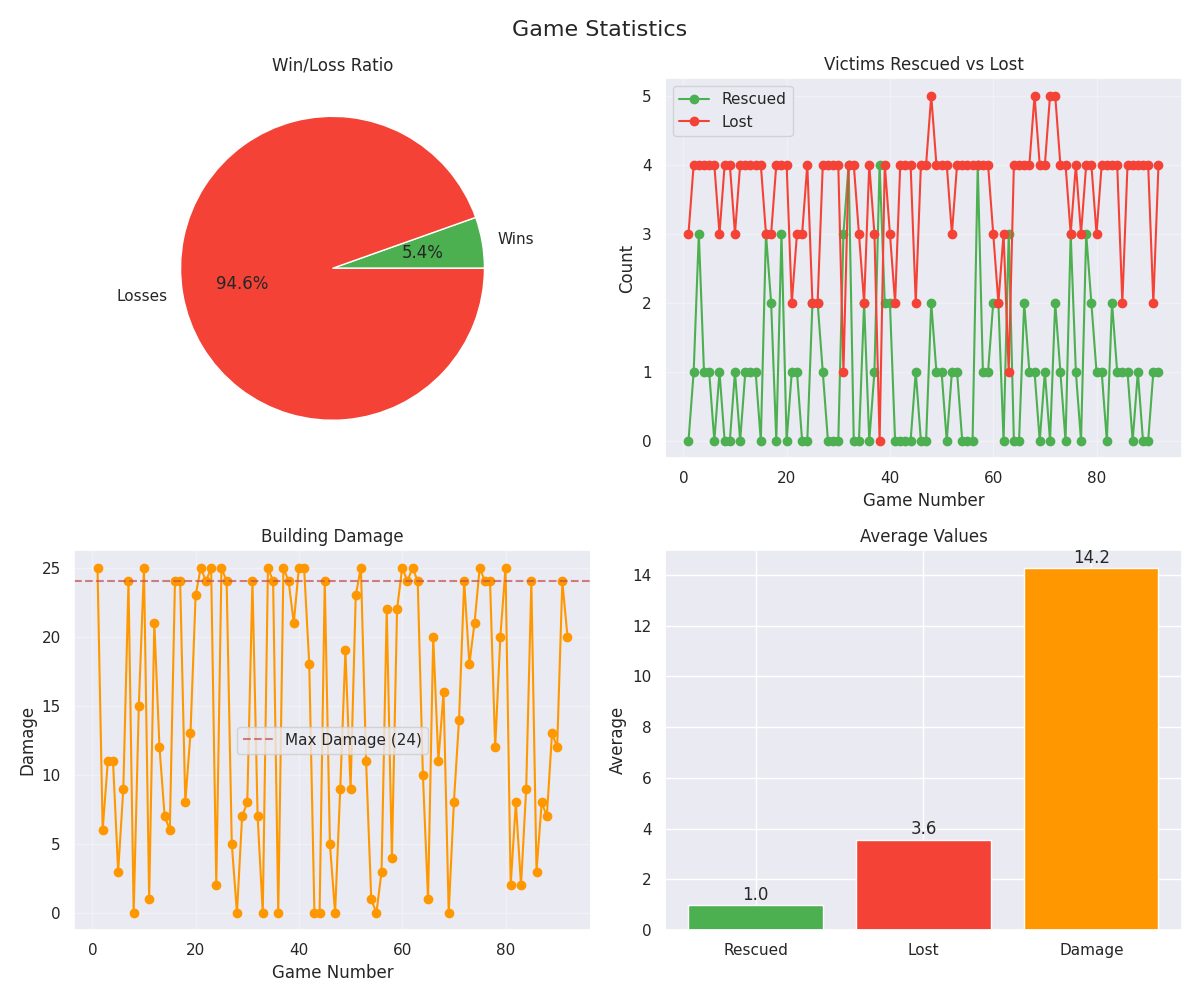


=== LAST GAME STATISTICS ===
Final Turn: 10
Victims Rescued: 1/7
Victims Lost: 4
Building Damage: 20/24


In [19]:
# === EJECUCIÓN ===
WIDTH = 10
HEIGHT = 8
MAX_TURNS = 100
NUM_GAMES = 100  # Number of games to run

# Initialize global stats collector
global_stats = SimpleGameStats()

for game_number in range(1, NUM_GAMES + 1):
    print(f"Starting game {game_number}")

    # Create new model for each game, pass the global stats
    model = FlashGame(WIDTH, HEIGHT, stats=global_stats)

    # Run the simulation
    while model.running and model.current_turn < MAX_TURNS:
        model.step()

    print(f"Game {game_number} ended after {model.current_turn} turns!\n")

# After all games finish, show combined stats and save graphs once
global_stats.show_stats_with_graphs()

# === VISUALIZATION ===
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap
from mesa.datacollection import DataCollector

# Get all grid data from the last game only
all_grids = model.datacollector.get_model_vars_dataframe()

# Create custom color map
zombicide_cmap = ListedColormap([
    'white', 'black', 'brown', 'tan', 'lightblue',
    'blue', 'darkblue', 'yellow', 'green', 'orange',
    'red', 'purple'
])

# Create figure and axis for animation
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xticks(range(WIDTH))
ax.set_yticks(range(HEIGHT))
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(True, color='gray', linestyle='-', linewidth=0.5)

# Show first frame of the last game's grid
img = ax.imshow(all_grids.iloc[0, 0], cmap=zombicide_cmap, vmin=0, vmax=11)

# Legend for visualization
legend_elements = [
    plt.Rectangle((0,0),1,1, fc='black'),
    plt.Rectangle((0,0),1,1, fc='brown'),
    plt.Rectangle((0,0),1,1, fc='tan'),
    plt.Rectangle((0,0),1,1, fc='lightblue'),
    plt.Rectangle((0,0),1,1, fc='blue'),
    plt.Rectangle((0,0),1,1, fc='darkblue'),
    plt.Rectangle((0,0),1,1, fc='yellow'),
    plt.Rectangle((0,0),1,1, fc='green'),
    plt.Rectangle((0,0),1,1, fc='orange'),
    plt.Rectangle((0,0),1,1, fc='red'),
    plt.Rectangle((0,0),1,1, fc='purple')
]

ax.legend(legend_elements,
          ['Wall', 'Closed Door', 'Open Door', 'Sleeping Zombie',
           'Active Zombie', 'Killer Zombie', 'Unrevealed POI',
           'Victim', 'False Alarm', 'Survivor', 'Survivor + Victim'],
          loc='upper left', bbox_to_anchor=(1, 1))

# Animation update function
def animate(i):
    if i < len(all_grids):
        img.set_array(all_grids.iloc[i, 0])
    return [img]

# Create animation
anim = animation.FuncAnimation(fig, animate, frames=len(all_grids), interval=500, blit=True)

plt.tight_layout()
plt.show()

# === FINAL STATISTICS OF LAST GAME ===
print("\n=== LAST GAME STATISTICS ===")
print(f"Final Turn: {model.current_turn}")
print(f"Victims Rescued: {model.victims_rescued}/7")
print(f"Victims Lost: {model.victims_lost}")
print(f"Building Damage: {model.total_damage}/24")


In [20]:
anim